In [1]:
import numpy as np
import matplotlib.pyplot as plt
import struct
import astropy.io.fits as fits
import tools21cm as t2c
from sklearn.decomposition import FastICA
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib
matplotlib.style.use('/home/ppxjf3/paper_params.mplstyle') 


from astropy.cosmology import Planck13 as cosmoP
from astropy.cosmology import FlatLambdaCDM, LambdaCDM

import astropy.units as u
cosmo = FlatLambdaCDM(H0=71 * u.km / u.s / u.Mpc, Om0=0.27)


In [2]:
import matplotlib.font_manager
import matplotlib as mpl

column_width=240# call "\the\columnwidth" in LaTeX to find
ppi=72#default ppi, can be left the same

scale=2
fig_width=column_width/ppi*scale#inches
fig_height=3*scale#inches

##SET FONT SIZES
font_small_size = 9
font_medium_size = 12
font_bigger_size =14

plt.rc('font', size=font_small_size) # controls default text sizes
plt.rc('axes', titlesize=font_small_size) # fontsize of the axes title
plt.rc('axes', labelsize=font_medium_size) # fontsize of the x and y labels
plt.rc('xtick', labelsize=font_bigger_size) # fontsize of the tick labels
plt.rc('ytick', labelsize=font_bigger_size) # fontsize of the tick labels
plt.rc('legend', fontsize=font_small_size) # legend fontsize
plt.rc('figure', titlesize=font_bigger_size)


#correct font for MNRAS
#can be found at https://www.fontsquirrel.com/fonts/nimbus-roman-no9-l
#can be installed on Unix systems by putting unzipped folder in directory /home/{user}/.fonts
#run "fc-cache -v" in console to inform system of new font
#print(matplotlib.font_manager.findSystemFonts(fontpaths=None, fontext='ttf'))
#plt.rc('font', family='Nimbus Roman')
# mpl.rcParams["font.family"] = "Nimbus Roman"
# mpl.rcParams['mathtext.fontset'] = 'custom'
# mpl.rcParams['mathtext.rm'] = 'Nimbus Roman'
# mpl.rcParams['mathtext.it'] = 'Nimbus Roman:italic'
# mpl.rcParams['mathtext.bf'] = 'Nimbus Roman:bold'
"""
plt.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
plt.rc('text', usetex=True)
"""

#DPI of MNRAS is 300
mpl.rcParams['figure.dpi'] = 300/scale
# Set up a figure with four panels, with two rows and columns

In [3]:
def pearson_correl(x,y):
 return (np.sum((x-np.mean(x))*(y-np.mean(y))))/(np.sqrt(np.sum((x-np.mean(x))**2)*np.sum((y-np.mean(y))**2)))

In [4]:
def do_fastica(data, comps):
    shape = data.shape
    f_ica = FastICA(n_components=comps)
    #generate the 4 componets
    S = f_ica.fit_transform(data.reshape((shape[0]*shape[1],shape[2])))
    
    #get mixing matrix
    A = f_ica.mixing_
    
    #make model
    model_fICA = (np.matmul(A,S.T).T).reshape((shape[0],shape[1],shape[2]))
    
    #get resids
    resids_fICA = data - model_fICA #residuals 
    
    return model_fICA, resids_fICA

In [5]:
def zFromNu(nu):
    """
    Convert frequency of 21cm line to redshift
    
    Input: nu [MHz]
    """
    nu21 = 1.420405e3  #MHz
    return nu21/nu - 1.0

def NuFromz(z):
    """
    Convert frequency of 21cm line to redshift
    
    Input: nu [MHz]
    """
    nu21 = 1.420405e3  #MHz
    return nu21/(z + 1.0)

In [6]:
def correlation_graph(LC, RSD_LC, res_LC, res_RSD, freq, name):
    cc_LC = np.empty([res_LC.shape[2]])
    cc_RSD = np.empty([res_RSD.shape[2]])

    for ii in range(0,res_RSD.shape[2]):
        cc_LC[ii] = pearson_correl(res_LC[:,:,ii],LC[:,:,ii])
        cc_RSD[ii] = pearson_correl(res_RSD[:,:,ii],RSD_LC[:,:,ii])
    
    plt.plot(freq, cc_RSD, label = 'RSD')
    plt.plot(freq, cc_LC, label = 'LC')
    plt.ylabel('correlation')
    plt.xlabel('freq')
    plt.legend()
    plt.savefig('/home/ppxjf3/RSD_LC/comparison/graphs/' + name, dpi=330)
    plt.show()
    
    plt.plot(freq, cc_RSD - cc_LC)
    plt.ylabel('residual (cc_RSD - cc_LC)')
    plt.xlabel('freq')
    plt.show()

In [7]:
def get_lengths(nu_low, nu_hi, nu_mid, theta_FOV):
    z_lo = zFromNu(nu_low)
    z_mid = zFromNu(nu_mid)
    z_hi = zFromNu(nu_hi)
    
    L_para = cosmo.comoving_distance(z_lo) - cosmo.comoving_distance(z_hi)
    L_perp = cosmo.comoving_distance(z_mid) * (np.pi * theta_FOV / 180.0)
    return L_para/u.Mpc, L_perp/u.Mpc

In [8]:
def LC_Volume(nu_min, nu_max, FoV):
    z_lo = zFromNu(nu_min)
    z_hi = zFromNu(nu_max)
    
    r_min = cosmo.comoving_distance(z_lo)/u.Mpc
    r_max = cosmo.comoving_distance(z_hi)/u.Mpc
    height = np.abs(r_max - r_min)
    
    S1 = (r_min* (np.pi * FoV / 180.0))**2
    S2 = (r_max* (np.pi * FoV / 180.0))**2
    return (height/3)*(S1 + S2 + np.sqrt(S1*S2))

In [9]:

base = '/home/ppxjf3/RSD_LC/comparison/FINAL_LIGHTCONES_PEC_VEL_PAPER/'
npix=512
nfreq=201
#with open(base + 'LightconeRSD_N512_FOV1.0000_dnu0.10MHz_095.00MHz_075.00MHz_ds0.002976_div00.00_pv1_oneevent0_evo1_lcon0_dz_000.10.dat', "rb") as fid:
with open(base+'LightconeRSD_N512_FOV1.0000_dnu0.10MHz_095.00MHz_075.00MHz_ds0.003099_div00.00_pv1_oneevent0_evo1_lcon0_dz_000.10.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    RSD = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)

RSD_z01_nu01_1deg = np.array(RSD)*1e3
RSD_z01_nu01_1deg = RSD_z01_nu01_1deg.reshape(npix,npix,nfreq)
        
with open(base +"LightconeRSD_N512_FOV1.0000_dnu0.10MHz_095.00MHz_075.00MHz_ds0.007747_div00.00_pv1_oneevent0_evo1_lcon1_dz_000.10.dat", "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    LC = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)

LC_z01_nu01_1deg = np.array(LC)*1e3
LC_z01_nu01_1deg = LC_z01_nu01_1deg.reshape(npix,npix,nfreq)
"""
with open(base + 'LightconeRSD_N512_FOV1.0000_dnu0.10MHz_095.00MHz_055.00MHz_ds0.007747_div00.00_pv1_oneevent0_evo1_lcon1_dz_000.50.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    LC = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)
LC_z05_nu01_1deg = np.array(LC)*1e3
LC_z05_nu01_1deg = LC_z05_nu01_1deg.reshape(npix,npix,nfreq)

with open(base + 'LightconeRSD_N512_FOV1.0000_dnu0.50MHz_095.00MHz_075.00MHz_ds0.007747_div00.00_pv1_oneevent0_evo1_lcon1_dz_000.10.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    LC = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)
LC_z01_nu05_1deg = np.array(LC)*1e3
LC_z01_nu05_1deg = LC_z01_nu05_1deg.reshape(npix,npix,41)

with open(base + 'LightconeRSD_N512_FOV1.0000_dnu1.00MHz_095.00MHz_075.00MHz_ds0.007747_div00.00_pv1_oneevent0_evo1_lcon1_dz_000.10.dat', "rb") as fid:
    # Read the binary data from the file
    data = fid.read()

    # Unpack the binary data into a tuple of floats
    LC = struct.unpack('f' * (len(data) // struct.calcsize('f')), data)
LC_z01_nu1_1deg = np.array(LC)*1e3
LC_z01_nu1_1deg = LC_z01_nu1_1deg.reshape(npix,npix,21)
"""


'\nwith open(base + \'LightconeRSD_N512_FOV1.0000_dnu0.10MHz_095.00MHz_055.00MHz_ds0.007747_div00.00_pv1_oneevent0_evo1_lcon1_dz_000.50.dat\', "rb") as fid:\n    # Read the binary data from the file\n    data = fid.read()\n\n    # Unpack the binary data into a tuple of floats\n    LC = struct.unpack(\'f\' * (len(data) // struct.calcsize(\'f\')), data)\nLC_z05_nu01_1deg = np.array(LC)*1e3\nLC_z05_nu01_1deg = LC_z05_nu01_1deg.reshape(npix,npix,nfreq)\n\nwith open(base + \'LightconeRSD_N512_FOV1.0000_dnu0.50MHz_095.00MHz_075.00MHz_ds0.007747_div00.00_pv1_oneevent0_evo1_lcon1_dz_000.10.dat\', "rb") as fid:\n    # Read the binary data from the file\n    data = fid.read()\n\n    # Unpack the binary data into a tuple of floats\n    LC = struct.unpack(\'f\' * (len(data) // struct.calcsize(\'f\')), data)\nLC_z01_nu05_1deg = np.array(LC)*1e3\nLC_z01_nu05_1deg = LC_z01_nu05_1deg.reshape(npix,npix,41)\n\nwith open(base + \'LightconeRSD_N512_FOV1.0000_dnu1.00MHz_095.00MHz_075.00MHz_ds0.007747_div00

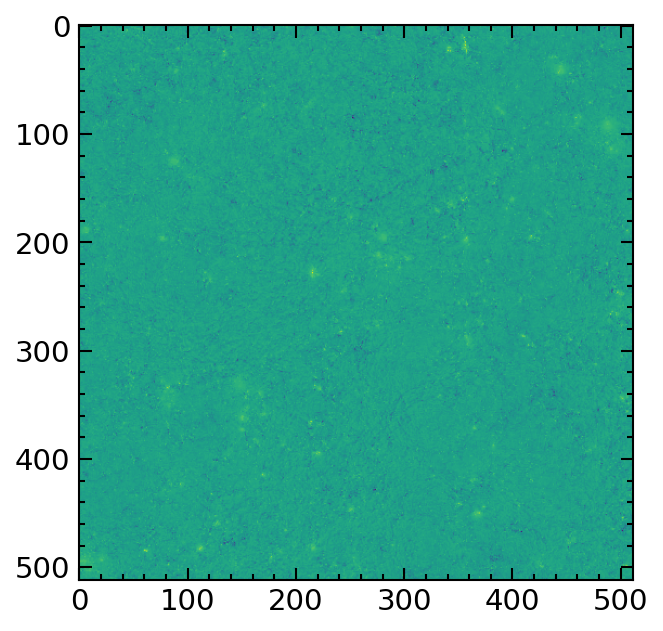

In [10]:
plt.imshow(RSD_z01_nu01_1deg[:,:,-1])

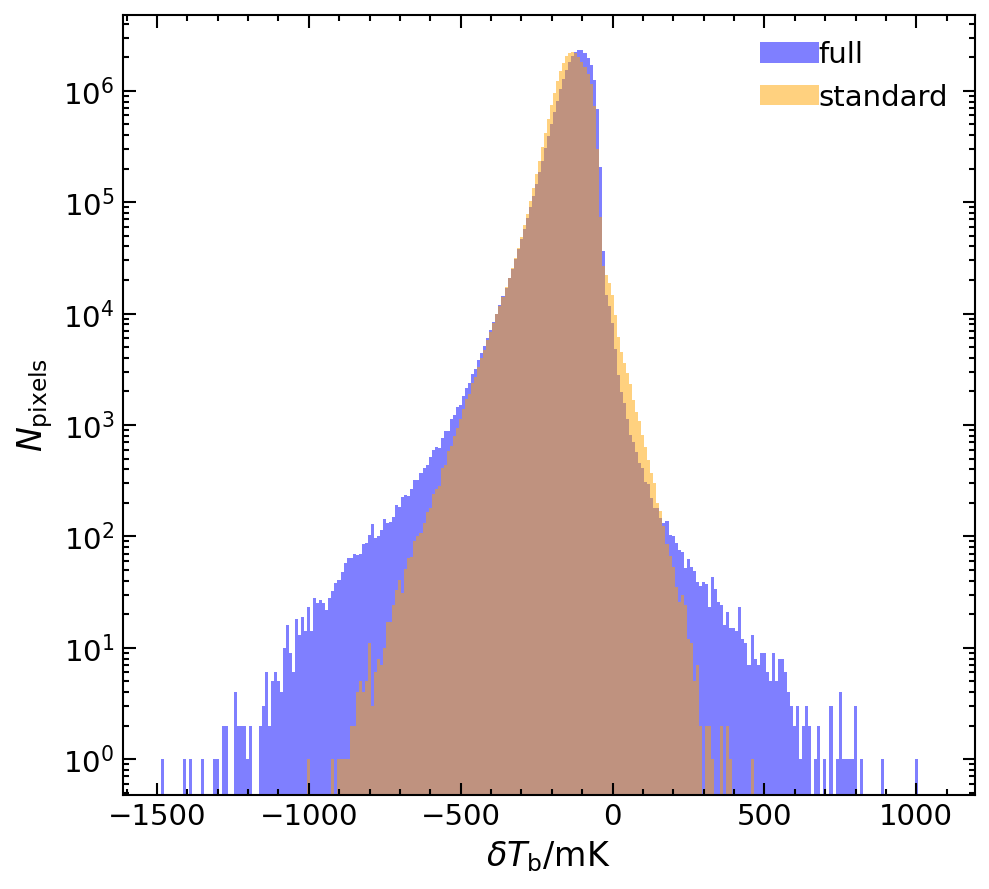

460.23043990135193
1066.7341947555542
-998.0857968330383
-1485.7851266860962


In [11]:
i0 = 50
i1 = 151

BINS = np.arange(np.min([LC_z01_nu01_1deg[:,:,i0:i1], RSD_z01_nu01_1deg[:,:,i0:i1]]), np.max([LC_z01_nu01_1deg[:,:,i0:i1], RSD_z01_nu01_1deg[:,:,i0:i1]]),10.0)

"""rsd_hist = np.hist(RSD_z01_nu01_1deg[:,:,i0:i1].reshape((512*512*101)), bins=BINS)
lc_hist = np.hist(LC_z01_nu01_1deg[:,:,i0:i1].reshape((512*512*101)), bins=BINS)
diff_hist = rsd_hist - """

fig, ax = plt.subplots(figsize=(fig_width, fig_height),
                       nrows=1, ncols=1,)
ax.hist(RSD_z01_nu01_1deg[:,:,i0:i1].reshape((512*512*101)), bins=BINS, color='blue', alpha=0.5, label='full')
ax.hist(LC_z01_nu01_1deg[:,:,i0:i1].reshape((512*512*101)), bins=BINS, color='orange', alpha=0.5, label='standard')
ax.set_yscale('log')
ax.set_ylabel(r'$N_{\rm pixels}$', fontsize=16)
ax.set_xlabel(r'$\delta T_{\rm b} /\rm mK$', fontsize=16)
plt.legend(frameon=False, fontsize=14)
plt.tight_layout()
plt.savefig(base + 'graphs_for_paper/CD_deltaTb_hist.pdf', dpi=330)
plt.show()

print(np.max(LC_z01_nu01_1deg[:,:,i0:i1]))
print(np.max(RSD_z01_nu01_1deg[:,:,i0:i1]))
print(np.min(LC_z01_nu01_1deg[:,:,i0:i1]))
print(np.min(RSD_z01_nu01_1deg[:,:,i0:i1]))

In [12]:
subset = np.where(RSD_z01_nu01_1deg[:,:,i0:i1].reshape(512*512*101)>np.max(LC_z01_nu01_1deg[:,:,i0:i1]))
print((len(np.array(subset).T)/len(RSD_z01_nu01_1deg[:,:,i0:i1].reshape((512*512*101))))*100)

subset = np.where(RSD_z01_nu01_1deg[:,:,i0:i1].reshape(512*512*101)<np.min(LC_z01_nu01_1deg[:,:,i0:i1]))
print((len(np.array(subset).T)/len(RSD_z01_nu01_1deg[:,:,i0:i1].reshape((512*512*101))))*100)


0.0004985544941212872
0.0006798470374381188


i0 = 0
i1 = 101

i2 = 100
i3 = 201

BINS = np.arange(0, 900,10.0)

BINS2 = np.arange(0, 900,10.0)

fig, ax = plt.subplots(figsize=(fig_width*2, fig_height),
                       nrows=1, ncols=2,)
fig.subplots_adjust(wspace=0)
#ax[0].hist(RSD_z01_nu1_1deg[:,:,i0:11].reshape((512*512*11)), bins=BINS, color='green', histtype='step', alpha=0.5, label=r'$\Delta \nu = 1.0$ full', density =True)
ax[0].hist(LC_z01_nu1_1deg[:,:,i0:11].reshape((512*512*11)), bins=BINS, color='red', histtype='step', alpha=0.5, label=r'$\Delta \nu = 1.0$ standard', density =True)
#ax[0].hist(RSD_z01_nu05_1deg[:,:,i0:21].reshape((512*512*21)), bins=BINS, color='blue', histtype='step', alpha=0.5, label=r'$\Delta \nu = 0.5$  full', density =True)
ax[0].hist(LC_z01_nu05_1deg[:,:,i0:21].reshape((512*512*21)), bins=BINS, color='orange', histtype='step', alpha=0.5, label=r'$\Delta \nu = 0.5$ standard', density =True)
ax[0].hist(RSD_z01_nu01_1deg[:,:,i0:i1].reshape((512*512*101)), bins=BINS, color='k', histtype='step', alpha=0.5, label=r'$\Delta \nu = 0.1$ full', density =True)
ax[0].hist(LC_z01_nu01_1deg[:,:,i0:i1].reshape((512*512*101)), bins=BINS, color='purple', histtype='step', alpha=0.5, label=r'$\Delta \nu = 0.1$  standard', density =True)
ax[0].text(0.35,0.95, r'$\nu = 80 \rm MHz$',transform=ax[0].transAxes, ha='right', va='top', fontsize=14)
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$\rm PDF$', fontsize=16)
ax[0].set_xlabel(r'$\delta T_b / \rm mK$', fontsize=16)
ax[0].texts

#ax[1].hist(RSD_z01_nu1_1deg[:,:,30:41].reshape((512*512*11)), bins=BINS2, color='green', histtype='step', alpha=0.5, label='z space 1 full', density =True)
ax[1].hist(LC_z01_nu1_1deg[:,:,10:21].reshape((512*512*11)), bins=BINS2, color='red', histtype='step', alpha=0.5, label='z space 1 standard', density =True)
#ax[1].hist(RSD_z01_nu05_1deg[:,:,60:81].reshape((512*512*21)), bins=BINS2, color='blue', histtype='step', alpha=0.5, label='z space 0.5 full', density =True)
ax[1].hist(LC_z01_nu05_1deg[:,:,20:41].reshape((512*512*21)), bins=BINS2, color='orange', histtype='step', alpha=0.5, label='z space 0.5 standard', density =True)
ax[1].hist(RSD_z01_nu01_1deg[:,:,i2:i3].reshape((512*512*101)), bins=BINS2, histtype='step', color='k', alpha=0.5, label='z space 0.1 full', density =True)
ax[1].hist(LC_z01_nu01_1deg[:,:,i2:i3].reshape((512*512*101)), bins=BINS2, color='purple', histtype='step', alpha=0.5, label='z space 0.1 standard', density =True)
ax[1].text(0.35,0.95, r'$\nu = 90 \rm MHz$',transform=ax[1].transAxes, ha='right', va='top', fontsize=14)
ax[1].set_yscale('log')
ax[1].set_ylabel(r'$\rm PDF$', fontsize=16)
ax[1].set_xlabel(r'$\delta T_b /\rm mK$', fontsize=16)

ax[0].legend(frameon=False, fontsize=14)
plt.tight_layout()
#plt.savefig(base + 'graphs_for_paper/freq_resolution_hist.pdf', dpi=330)
plt.show()

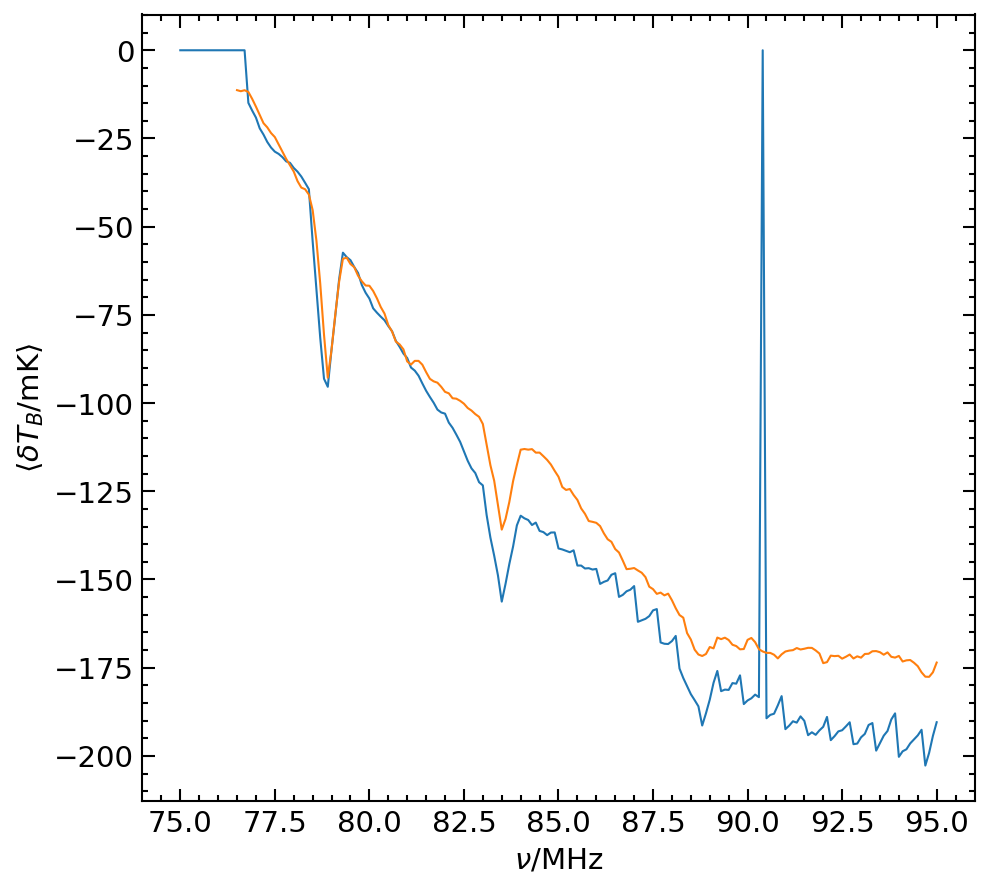

[[  0]
 [  1]
 [  2]
 [  3]
 [  4]
 [  5]
 [  6]
 [  7]
 [  8]
 [  9]
 [ 10]
 [ 11]
 [ 12]
 [ 13]
 [ 14]
 [ 15]
 [ 16]
 [ 17]
 [154]]


In [10]:
freq01 = np.arange(75, 95.1, 0.1)
#freq05 = np.arange(75, 95.5, 0.5)
#freq1 = np.arange(75, 96, 1)

#TB_LC_z01_nu1_1deg = np.empty([LC_z01_nu1_1deg.shape[2]])
#TB_RSD_z01_nu1_1deg = np.empty([RSD_z01_nu1_1deg.shape[2]])
#TB_RSD_z01_nu05_1deg = np.empty([RSD_z01_nu05_1deg.shape[2]])
#TB_LC_z01_nu05_1deg = np.empty([LC_z01_nu05_1deg.shape[2]])
TB_RSD_z01_nu01_1deg = np.empty([RSD_z01_nu01_1deg.shape[2]])
TB_LC_z01_nu01_1deg = np.empty([LC_z01_nu01_1deg.shape[2]])

for ii in range(0,RSD_z01_nu01_1deg.shape[2]):
    TB_LC_z01_nu01_1deg[ii] = np.mean(LC_z01_nu01_1deg[:,:,ii])
    TB_RSD_z01_nu01_1deg[ii] = np.mean(RSD_z01_nu01_1deg[:,:,ii])
#for ii in range(0,LC_z01_nu05_1deg.shape[2]):
#    #TB_RSD_z01_nu05_1deg[ii] = np.mean(RSD_z01_nu05_1deg[:,:,ii])
#    TB_LC_z01_nu05_1deg[ii] = np.mean(LC_z01_nu05_1deg[:,:,ii])
#for ii in range(0,LC_z01_nu1_1deg.shape[2]):
#    TB_LC_z01_nu1_1deg[ii] = np.mean([LC_z01_nu1_1deg[:,:,ii]])
#    #TB_RSD_z01_nu1_1deg[ii] = np.mean([RSD_z01_nu1_1deg[:,:,ii]])
    
    


fig, ax = plt.subplots(figsize=(fig_width, fig_height),
                       nrows=1, ncols=1,)
#ax[0].plot(freq1, TB_LC_z01_nu1_1deg, label=r'$\Delta \nu = 1.0 $')
#ax[0].plot(freq05, TB_LC_z01_nu05_1deg, label=r'$\Delta \nu = 0.5 $')
ax.plot(freq01, TB_LC_z01_nu01_1deg, label=r'$\Delta \nu =0.1 $')
ax.set_ylabel(r'$\langle \delta T_B /\rm mK \rangle $', fontsize=14)
#ax[0].text(0.2,0.15, 'standard',transform=ax[0].transAxes, ha='right', va='top', fontsize=13)
ax.set_xlabel(r'$\nu / \rm MHz$', fontsize=14)
#ax[0].set_xlim(140,180)
#ax[1].plot(freq1, TB_RSD_z01_nu1_1deg, label=r'$\Delta \nu = 1.0 $ ')
#ax[1].plot(freq05, TB_RSD_z01_nu05_1deg, label=r'$\Delta \nu = 0.5 $ ')
ax.plot(freq01, TB_RSD_z01_nu01_1deg, label=r'$\Delta \nu =0.1 $ ')
#ax[1].set_ylabel(r'$\langle \delta T_B /\rm mK \rangle $', fontsize=14)
#ax[1].text(0.15,0.15, 'full',transform=ax[1].transAxes, ha='right', va='top', fontsize=13)
#ax[1].set_xlabel(r'$\nu / \rm MHz$', fontsize=14)
#ax[1].set_xlim(140,180)
plt.tight_layout()
#plt.legend(frameon=False, fontsize=14)
#plt.savefig(base + 'graphs_for_paper/freq_resolution_global_temp.pdf', dpi=330)
plt.show()

print(np.argwhere(TB_LC_z01_nu01_1deg==0))

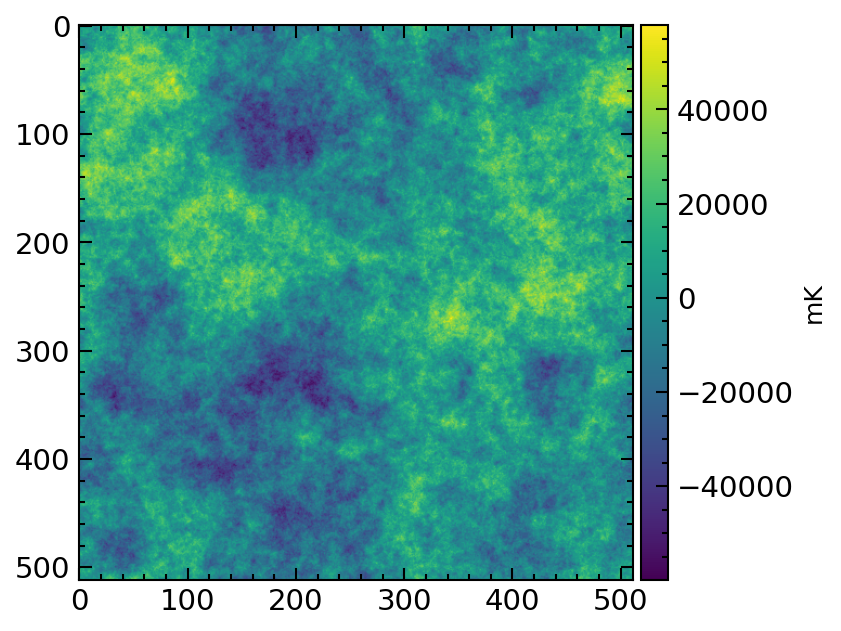

In [10]:

with fits.open(base + 'Fg_N512_FOV1.0_75_95.0MHz_0.1MHz.fits', memmap=True) as hdu:
    FG = np.array(hdu[0].data)  
    
FG=FG*1e3
fig, ax = plt.subplots(1,1)
pmc_lc_cd = ax.imshow(FG[:,:,20])
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(pmc_lc_cd, cax=cax, orientation='vertical', label='mK')

plt.imshow(LC_z01_nu01_1deg[:,:,154])


In [11]:
FG_LC = FG + LC_z01_nu01_1deg
FG_RSD = FG + RSD_z01_nu01_1deg

freq01 = np.arange(75, 95.1, 0.1)

In [12]:
c = 4
model1, resids_LC_FG = do_fastica(FG_LC, c)
model2, resids_RSD_FG = do_fastica(FG_RSD, c)




print('correlation between model from each lc {}'.format(pearson_correl(model1,model2)))

correlation_graph(LC_z01_nu01_1deg, RSD_z01_nu01_1deg, resids_LC_FG, resids_RSD_FG, freq01, 'EoR_Fg_4c_fastica_recovery_corre.pdf')

In [13]:
from scipy import interpolate
import matplotlib.colors as colors

plotting_scale={'x': 'log', 'y': 'log', 'z': 'log'}
bins = 8

i0 = 50
i1 = 151

L_para, L_perp = get_lengths(freq01[i0], freq01[i1], (freq01[i0]+freq01[i1])/2, 1.0)
box_dims = [L_perp, L_perp, L_para]

pp_RSD, kper_RSD, kpar_RSD, n_RSD = t2c.power_spectrum_2d(RSD_z01_nu01_1deg[:,:,i0:i1], kbins=bins, box_dims= box_dims, return_modes=True)
for ii in range(0,len(kper_RSD)):
    for jj in range(0,len(kpar_RSD)):
        pp_RSD[ii,jj] = (pp_RSD[ii,jj]*np.sqrt(kper_RSD[ii]**2 + kpar_RSD[jj]**2)**3)/(2*np.pi**2)
fp_RSD = interpolate.interp2d(kper_RSD, kpar_RSD, pp_RSD.T, kind='linear')
X_RSD, Y_RSD = kper_RSD, kpar_RSD
C_RSD = fp_RSD(X_RSD,Y_RSD)
norm_RSD = colors.LogNorm(vmin=C_RSD[np.isfinite(C_RSD)].min(), vmax=C_RSD[np.isfinite(C_RSD)].max()) if plotting_scale['z']=='log' else None 

pp_RSD_RES, kper_RSD_RES, kpar_RSD_RES, n_RSD_RES = t2c.power_spectrum_2d(resids_RSD_FG[:,:,i0:i1], kbins=bins, box_dims= box_dims, return_modes=True)
for ii in range(0,len(kper_RSD_RES)):
    for jj in range(0,len(kpar_RSD_RES)):
        pp_RSD_RES[ii,jj] = (pp_RSD_RES[ii,jj]*np.sqrt(kper_RSD_RES[ii]**2 + kpar_RSD_RES[jj]**2)**3)/(2*np.pi**2)
err_RSD_RES = 1/np.sqrt(n_RSD_RES)
fp_RSD_RES = interpolate.interp2d(kper_RSD_RES, kpar_RSD_RES, pp_RSD_RES.T, kind='linear')
X_RSD_RES, Y_RSD_RES = kper_RSD_RES, kpar_RSD_RES
C_RSD_RES = fp_RSD_RES(X_RSD_RES,Y_RSD_RES)
norm_RSD_RES = colors.LogNorm(vmin=C_RSD_RES[np.isfinite(C_RSD_RES)].min(), vmax=C_RSD_RES[np.isfinite(C_RSD_RES)].max()) if plotting_scale['z']=='log' else None 


pp_LC, kper_LC, kpar_LC, n_LC = t2c.power_spectrum_2d(LC_z01_nu01_1deg[:,:,i0:i1], kbins=bins, box_dims= box_dims, return_modes=True)
for ii in range(0,len(kper_LC)):
    for jj in range(0,len(kpar_LC)):
        pp_LC[ii,jj] = (pp_LC[ii,jj]*np.sqrt(kper_LC[ii]**2 + kpar_LC[jj]**2)**3)/(2*np.pi**2)
fp_LC = interpolate.interp2d(kper_LC, kpar_LC, pp_LC.T, kind='linear')
X_LC, Y_LC = kper_LC, kpar_LC
C_LC = fp_LC(X_LC,Y_LC)
norm_LC = colors.LogNorm(vmin=C_LC[np.isfinite(C_LC)].min(), vmax=C_LC[np.isfinite(C_LC)].max()) if plotting_scale['z']=='log' else None 


pp_LC_RES, kper_LC_RES, kpar_LC_RES, n_LC_RES = t2c.power_spectrum_2d(resids_LC_FG[:,:,i0:i1], kbins=bins, box_dims= box_dims, return_modes=True)
for ii in range(0,len(kper_LC_RES)):
    for jj in range(0,len(kpar_LC_RES)):
        pp_LC_RES[ii,jj] = (pp_LC_RES[ii,jj]*np.sqrt(kper_LC_RES[ii]**2 + kpar_LC_RES[jj]**2)**3)/(2*np.pi**2)
err_LC_RES = 1/np.sqrt(n_LC_RES)
fp_LC_RES = interpolate.interp2d(kper_LC_RES, kpar_LC_RES, pp_LC_RES.T, kind='linear')
X_LC_RES, Y_LC_RES = kper_LC_RES, kpar_LC_RES
C_LC_RES = fp_LC_RES(X_LC_RES,Y_LC_RES)
norm_LC_RES = colors.LogNorm(vmin=C_LC_RES[np.isfinite(C_LC_RES)].min(), vmax=C_LC_RES[np.isfinite(C_LC_RES)].max()) if plotting_scale['z']=='log' else None 

C_tot = np.concatenate((C_LC, C_RSD, C_LC_RES, C_RSD_RES))

norm_tot = colors.LogNorm(vmin=C_tot[np.isfinite(C_tot)].min(), vmax=C_tot[np.isfinite(C_tot)].max()) if plotting_scale['z']=='log' else None 

C_diff =(np.abs(C_RSD - C_LC)/C_LC)*100

norm_diff = colors.LogNorm(vmin=C_diff[np.isfinite(C_diff)].min(), vmax=C_diff[np.isfinite(C_diff)].max()) if plotting_scale['z']=='log' else None 


C_diff_res =  (np.abs(C_RSD_RES - C_LC_RES)/C_LC_RES)*100
norm_diff_res = colors.LogNorm(vmin=C_diff_res[np.isfinite(C_diff_res)].min(), vmax=C_diff_res[np.isfinite(C_diff_res)].max()) if plotting_scale['z']=='log' else None 

C_tot_diff = np.concatenate((C_diff, C_diff_res))
norm_tot_diff = colors.LogNorm(vmin=C_tot_diff[np.isfinite(C_tot_diff)].min(), vmax=C_tot_diff[np.isfinite(C_tot_diff)].max()) if plotting_scale['z']=='log' else None 


print(pearson_correl(C_diff_res.reshape(8*8),C_diff.reshape(8*8)))

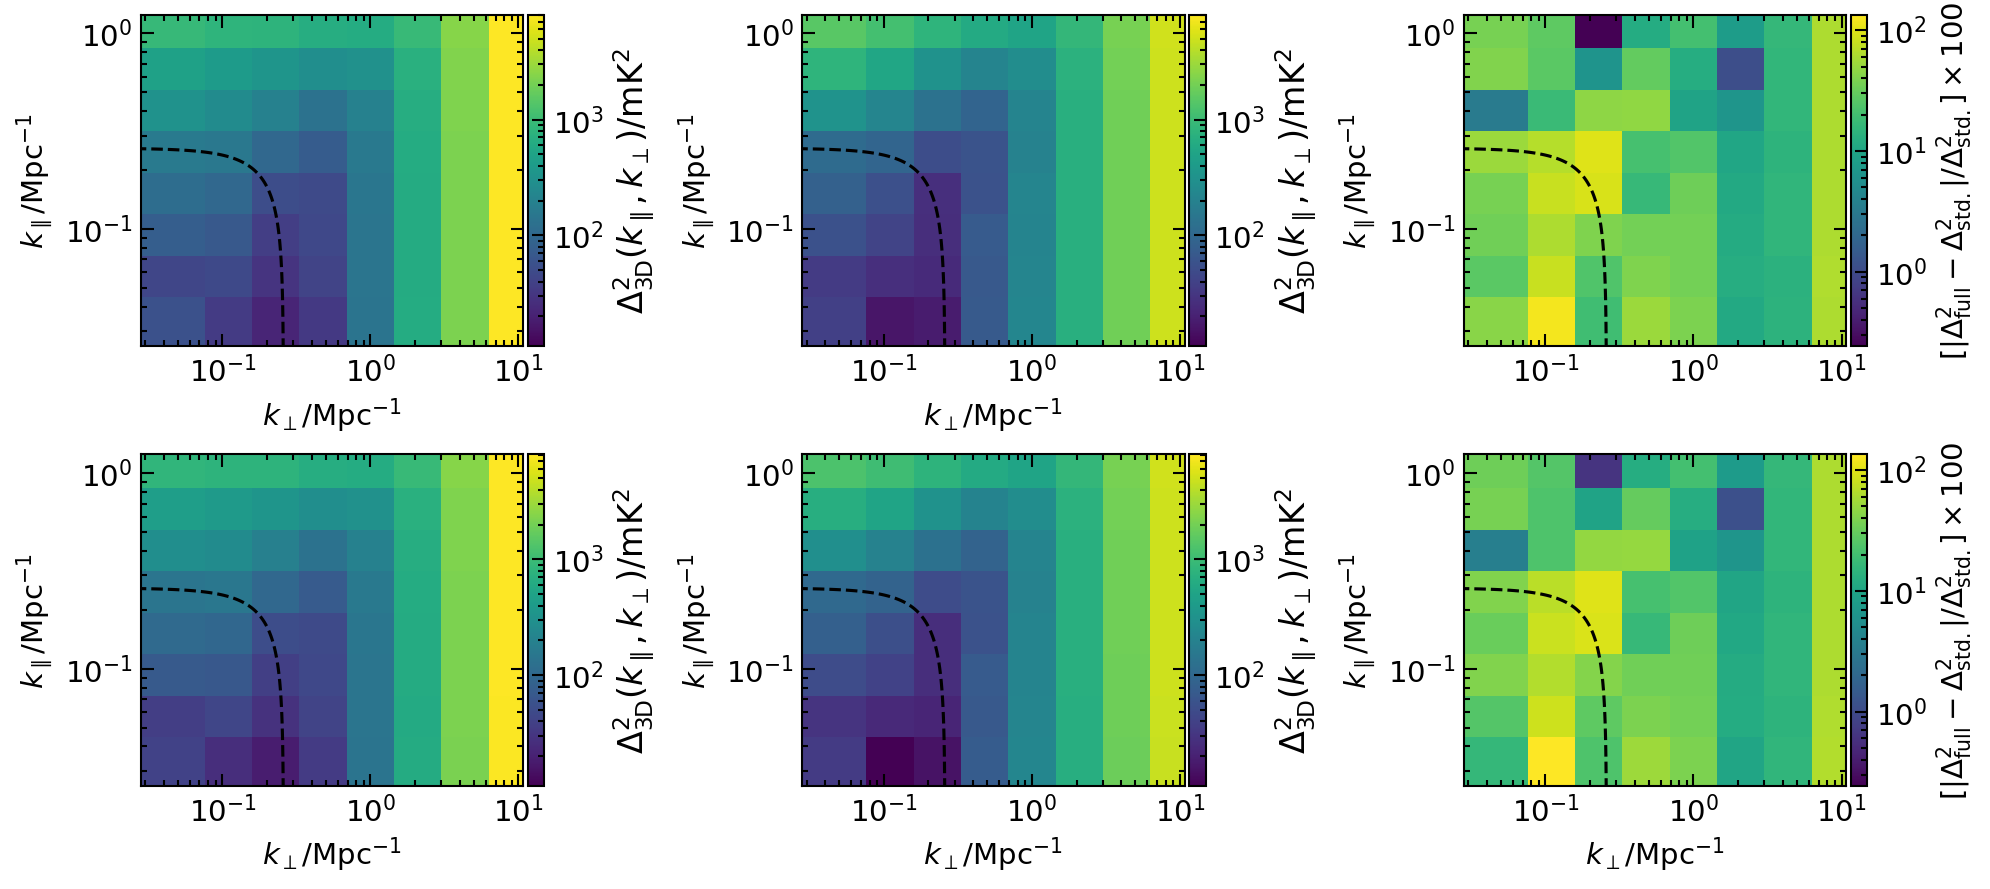

In [14]:

import matplotlib.font_manager
import matplotlib as mpl

k_mag =  0.2585
theta = np.linspace(0, 2*np.pi, 500)
k_par = k_mag * np.cos(theta)
k_perp = k_mag * np.sin(theta)
mask = (k_par > 0) & (k_perp > 0)

fig, ax = plt.subplots(figsize=(2*fig_width, fig_height),
                       nrows=2, ncols=3,)
    

pcm_RSD = ax[0,0].pcolormesh(X_RSD, Y_RSD, C_RSD, norm=norm_tot, cmap='viridis')
cbar= plt.colorbar(pcm_RSD, ax=ax[0,0], pad=0.01)
cbar.set_label(r'$\Delta^2_{\rm 3D}(k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
ax[0,0].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[0,0].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[0,0].set_xscale(plotting_scale['x'])
ax[0,0].set_yscale(plotting_scale['y'])
ax[0,0].plot(k_perp[mask], k_par[mask], color='k', lw=1.5, linestyle='--', label=r'$|\vec{k}| = 40$')
ax[0,0].set_ylim(0.025,1.25)
ax[0,0].set_xlim(left=0.028)

pcm_LC = ax[0,1].pcolormesh(X_LC, Y_LC, C_LC, norm=norm_tot, cmap='viridis')
cbar = plt.colorbar(pcm_LC, ax=ax[0,1], pad=0.01)
cbar.set_label(r'$\Delta^2_{\rm 3D}(k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
ax[0,1].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[0,1].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[0,1].set_xscale(plotting_scale['x'])
ax[0,1].set_yscale(plotting_scale['y'])
ax[0,1].plot(k_perp[mask], k_par[mask], color='k', lw=1.5, linestyle='--', label=r'$|\vec{k}| = 40$')
ax[0,1].set_ylim(0.025,1.25)
ax[0,1].set_xlim(left=0.028)

pcm_LC = ax[0,2].pcolormesh(X_LC, Y_LC, C_diff, norm=norm_tot_diff, cmap='viridis')
cbar= plt.colorbar(pcm_LC, ax=ax[0,2], pad=0.01)
cbar.set_label(r'$[|\Delta^2_{\rm full} - \Delta^2_{\rm std.}|/\Delta^2_{\rm std.}] \times 100 $', size=14) 
ax[0,2].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[0,2].set_xscale(plotting_scale['x'])
ax[0,2].set_yscale(plotting_scale['y'])
ax[0,2].plot(k_perp[mask], k_par[mask], color='k', lw=1.5, linestyle='--', label=r'$|\vec{k}| = 40$')
ax[0,2].set_ylim(0.025,1.25)
ax[0,2].set_xlim(left=0.028)    

pcm_RSD_RES = ax[1,0].pcolormesh(X_RSD_RES, Y_RSD_RES, C_RSD_RES, norm=norm_tot, cmap='viridis')
cbar= plt.colorbar(pcm_RSD_RES, ax=ax[1,0], pad=0.01)
cbar.set_label(r'$\Delta^2_{\rm 3D}(k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
ax[1,0].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[1,0].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[1,0].set_xscale(plotting_scale['x'])
ax[1,0].set_yscale(plotting_scale['y'])
ax[1,0].plot(k_perp[mask], k_par[mask], color='k', lw=1.5, linestyle='--', label=r'$|\vec{k}| = 40$')
ax[1,0].set_ylim(0.025,1.25)
ax[1,0].set_xlim(left=0.028)

pcm_LC_RES = ax[1,1].pcolormesh(X_LC_RES, Y_LC_RES, C_LC_RES, norm=norm_tot, cmap='viridis')
cbar= plt.colorbar(pcm_LC_RES, ax=ax[1,1], pad=0.01)
cbar.set_label(r'$\Delta^2_{\rm 3D}(k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
ax[1,1].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[1,1].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[1,1].set_xscale(plotting_scale['x'])
ax[1,1].set_yscale(plotting_scale['y'])
ax[1,1].plot(k_perp[mask], k_par[mask], color='k', lw=1.5, linestyle='--', label=r'$|\vec{k}| = 40$')
ax[1,1].set_ylim(0.025,1.25)
ax[1,1].set_xlim(left=0.028)  

pcm_LC_RES = ax[1,2].pcolormesh(X_LC_RES, Y_LC_RES, C_diff_res, norm=norm_tot_diff, cmap='viridis')
cbar= plt.colorbar(pcm_LC_RES, ax=ax[1,2], pad=0.01)
cbar.set_label(r'$[|\Delta^2_{\rm full} - \Delta^2_{\rm std.}|/\Delta^2_{\rm std.}] \times 100 $', size=14) 
ax[1,2].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[1,2].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[1,2].set_xscale(plotting_scale['x'])
ax[1,2].set_yscale(plotting_scale['y'])
ax[1,2].plot(k_perp[mask], k_par[mask], color='k', lw=1.5, linestyle='--', label=r'$|\vec{k}| = 40$')
ax[1,2].set_ylim(0.025,1.25)
ax[1,2].set_xlim(left=0.028)
 
plt.tight_layout()
plt.savefig(base + 'graphs_for_paper/cyclindrical_powerSpec_FGremoval_512_80-90MHz.pdf', dpi=330, bbox_inches='tight')
plt.show()

In [15]:
kbins=12
mubins=15
    
Pk_lc, mubins_lc, kbins_lc, nmode_lc = t2c.power_spectrum_mu(LC_z01_nu01_1deg[:,:,i0:i1], los_axis = 2, box_dims=box_dims, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)
Pk_reslc, mubins_reslc, kbins_reslc, nmode_reslc = t2c.power_spectrum_mu(resids_LC_FG[:,:,i0:i1], los_axis = 2, box_dims=box_dims, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)

Pk_rsd, mubins_rsd, kbins_rsd, nmode_rsd = t2c.power_spectrum_mu(RSD_z01_nu01_1deg[:,:,i0:i1], los_axis = 2, box_dims=box_dims, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)
Pk_resrsd, mubins_resrsd, kbins_resrsd, nmode_resrsd = t2c.power_spectrum_mu(resids_RSD_FG[:,:,i0:i1], box_dims=box_dims, los_axis = 2, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)


In [16]:
dk_lc = (Pk_lc*kbins_lc**3)/(2*np.pi**2)
dk_rsd = (Pk_rsd*kbins_rsd**3)/(2*np.pi**2)
dk_lc_res = (Pk_reslc*kbins_reslc**3)/(2*np.pi**2)
dk_rsd_res = (Pk_resrsd*kbins_resrsd**3)/(2*np.pi**2)


In [17]:
#calculate errors
err_lc_res= np.empty_like(nmode_reslc)
err_rsd_res= np.empty_like(nmode_resrsd)

for ii in range(0,nmode_lc.shape[0]):
    for jj in range(0,nmode_lc.shape[1]):
        err_lc_res[ii, jj] = dk_lc_res[ii, jj]/np.sqrt(nmode_reslc[ii, jj])
        
        err_rsd_res[ii, jj] = dk_rsd_res[ii, jj]/np.sqrt(nmode_resrsd[ii,jj])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


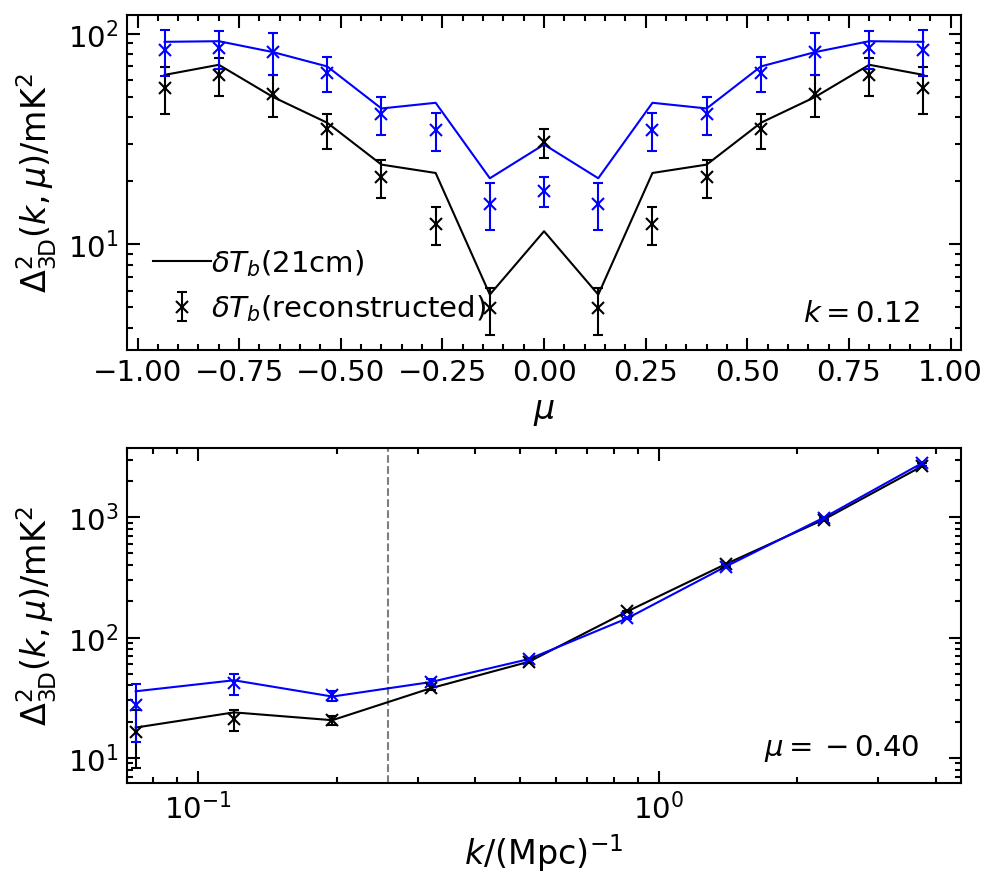

In [18]:
ii = 2
jj = 4

import matplotlib.ticker as ticker

def format_ticks(value, pos):
    """Format ticks to show integers while maintaining the logarithmic scale."""
    exponent = int(np.log10(value))
    mantissa = value / (10 ** exponent)
    if np.isclose(mantissa, 1.0):  # Only show ticks at powers of ten
        return f'$10^{{{exponent}}}$'
    return ''

fig, ax = plt.subplots(figsize=(fig_width, fig_height), nrows=2, ncols=1)

# Upper panel
ax[0].plot(mubins_lc, dk_lc[:, ii], color='k', label=r'$\delta T_b(21 \rm cm)$')
ax[0].errorbar(mubins_lc, dk_lc_res[:, ii], err_lc_res[:, ii], color='k', ls='none', capsize=2.5, label=r'$\delta T_b(\rm reconstructed)$', marker='x')
ax[0].plot(mubins_rsd, dk_rsd[:, ii], color='b')
ax[0].errorbar(mubins_resrsd, dk_rsd_res[:, ii], err_rsd_res[:, ii], color='b', ls='none', capsize=2.5, marker='x')
#freq_ticks = [0.0001, 0.0002]

# Set the tick locations on the secondary x-axis
#ax[0].set_xticks(freq_ticks)  # Set the tick positions in MHz
ax[0].set_yscale('log')
ax[0].set_xlabel(r'$\mu$', fontsize=16)
ax[0].set_ylabel(r'$\Delta^2_{\rm 3D}(k,\mu)/ \rm mK^2$', fontsize=16)
ax[0].text(0.95, 0.15, r' $k={0:.2f}$'.format(kbins_lc[ii]), transform=ax[0].transAxes, ha='right', va='top', fontsize=14)
ax[0].legend(frameon=False, fontsize=14)


# Lower panel
ax[1].plot(kbins_lc, dk_lc[jj, :], color='k')
ax[1].errorbar(kbins_reslc, dk_lc_res[jj, :], err_lc_res[jj, :], color='k', ls='none', capsize=2.5, marker='x')
ax[1].plot(kbins_rsd, dk_rsd[jj, :], color='b')
ax[1].errorbar(kbins_resrsd, dk_rsd_res[jj, :], err_rsd_res[jj, :], color='b', ls='none', capsize=2.5, marker='x')
ax[1].set_xlabel(r'$k/(\rm Mpc)^{-1}$', fontsize=16)
ax[1].set_ylabel(r'$\Delta^2_{\rm 3D}(k,\mu)/ \rm mK^2$', fontsize=16)
ax[1].text(0.95, 0.15, r' $\mu={0:.2f}$'.format(mubins_lc[jj]), transform=ax[1].transAxes, ha='right', va='top', fontsize=14)
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].axvline(0.2585, linestyle='dashed', color='k', alpha=0.5)
ax[1].set_xlim(left = 0.07)
ax[1].legend(frameon=False, fontsize=14)

plt.tight_layout()
plt.savefig(base + 'graphs_for_paper/mu_ps_fg_removal_cd.pdf', dpi=330)
plt.show()


In [ ]:
  
p_lc_eor_res, k_lc_eor_res, n_lc_res = t2c.power_spectrum_1d(resids_LC_FG[:,:,i0:i1], kbins=kbins, box_dims=box_dims, binning =  'log', return_n_modes=True)
p_rsd_lc_eor_res, k_rsd_lc_eor_res, n_rsd_res = t2c.power_spectrum_1d(resids_RSD_FG[:,:,i0:i1], box_dims=box_dims, kbins=kbins, binning =  'log', return_n_modes=True)
p_lc_eor, k_lc_eor, n_lc = t2c.power_spectrum_1d(LC_z01_nu01_1deg[:,:,i0:i1], kbins=kbins, box_dims=box_dims, binning =  'log', return_n_modes=True)
p_rsd, k_rsd, n_rsd = t2c.power_spectrum_1d(RSD_z01_nu01_1deg[:,:,i0:i1], box_dims=box_dims, kbins=kbins, binning =  'log', return_n_modes=True)



In [ ]:
d_lc = (p_lc_eor*V_eor*k_lc_eor**3)/(2*np.pi**2)
d_rsd = (p_rsd*V_eor*k_rsd**3)/(2*np.pi**2)
d_lc_res = (p_lc_eor_res*V_eor*k_lc_eor_res**3)/(2*np.pi**2)
d_rsd_res = (p_rsd_lc_eor_res*V_eor*k_rsd_lc_eor_res**3)/(2*np.pi**2)


#calculate errors
err_lc_res= np.empty_like(n_lc_res)
err_rsd_res= np.empty_like(n_lc_res)

for ii in range(0,n_lc_res.shape[0]):
    err_lc_res[ii] = d_lc_res[ii]/np.sqrt(n_lc_res[ii])
        
    err_rsd_res[ii] = d_rsd_res[ii]/np.sqrt(n_rsd_res[ii])

In [ ]:
#lightcone standard
fig, ax = plt.subplots(figsize=(fig_width, fig_height),
                       nrows=1, ncols=1,)

ax.plot(k_lc_eor, d_lc, color='k')
ax.plot(k_rsd, d_rsd, color='b')
ax.plot(k_lc_eor, d_lc, color='k', label = r'$\delta T_b(21 \rm cm)$')
ax.errorbar(k_lc_eor_res, d_lc_res, err_lc_res, color='k', ls='none', capsize = 2.5, label = r'$\delta T_b(\rm reconstructed)$')
ax.errorbar(k_rsd_lc_eor_res, d_rsd_res, err_rsd_res, color='b', ls='none', capsize = 2.5)

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'$k/(\rm Mpc/h)^{-1}$', fontsize=16)
ax.set_ylabel(r'$\Delta_{\rm 3D} ^2(k)/\rm mK^2$', fontsize = 16)
ax.legend(frameon=False, fontsize = 14)

plt.tight_layout()
plt.savefig(base + 'graphs_for_paper/cd_3d_ps_fg_removal.pdf', dpi=330)
plt.show()

print((np.abs(d_rsd[-1]-d_lc[-1])/d_lc[-1])*100)
print((np.abs(d_rsd_res[-1]-d_lc_res[-1])/d_lc_res[-1])*100)

In [16]:
#add noise
with fits.open('/home/ppxjf3/RSD_LC/comparison/FINAL_LIGHTCONES_PEC_VEL_PAPER/NOISE_I_75-95_SKA_central_area_Rev3_EOR0_1.0degree_1000hrs.fits', memmap=True) as hdu:
    NOISE =np.array(hdu[0].data) #10MHz centered on 166MHz
    hdu.info()

NOISE = NOISE *1e3


NOISE = np.transpose(NOISE, (1,2,0))
NOISE = NOISE[:,:,0:201]
FG_LC_NOISE = FG_LC + NOISE
FG_RSD_NOISE = FG_RSD + NOISE



Filename: /home/ppxjf3/RSD_LC/comparison/FINAL_LIGHTCONES_PEC_VEL_PAPER/NOISE_I_75-95_SKA_central_area_Rev3_EOR0_1.0degree_1000hrs.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (512, 512, 401)   float64   


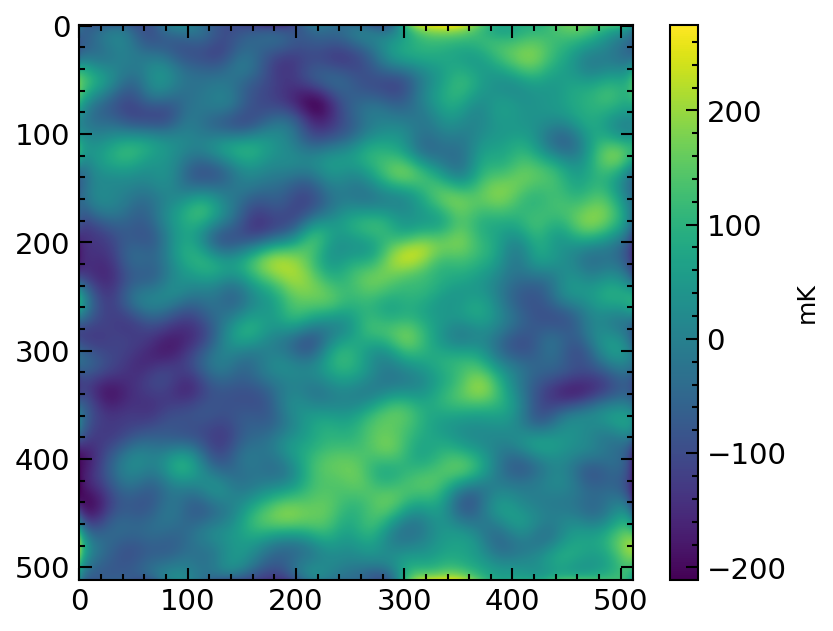

In [17]:
plt.imshow(NOISE[:,:,100])
plt.colorbar(label='mK')

In [18]:

LC_NOISE = LC_z01_nu01_1deg + NOISE
RSD_NOISE = RSD_z01_nu01_1deg + NOISE

In [19]:
c = 4
freq = np.arange(75, 95.1, 0.1)
model1, resids_LC_FG_NOISE = do_fastica(FG_LC_NOISE, c)

model2, resids_RSD_FG_NOISE = do_fastica(FG_RSD_NOISE, c)

print('correlation between model from each lc {}'.format(pearson_correl(model1,model2)))

correlation_graph(LC_NOISE, RSD_NOISE, resids_LC_FG_NOISE, resids_RSD_FG_NOISE, freq, 'EoR_NOISE_4c_fastica_recovery_corre.pdf')

ValueError: Input X contains NaN.
FastICA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
kbins=12
mubins=15
i0 = 50
i1 = 151  

L_para, L_perp = get_lengths(freq[i0], freq[i1], (freq[i0]+freq[i1])/2, 1.0)
box_dims = [L_perp, L_perp, L_para]
    
V_eor = LC_Volume(freq[i0], freq[i1], 1.0)
p_NOISE, k_NOISE, n_NOISE = t2c.power_spectrum_1d(NOISE[:,:,i0:i1], box_dims=box_dims, kbins=kbins, binning = 'log', return_n_modes=True)
d_NOISE = (p_NOISE*V_eor*k_NOISE**3)/(2*np.pi**2)

Pk_NOISE, mubins_NOISE, kbins_NOISE, nmode_NOISE = t2c.power_spectrum_mu(NOISE[:,:,i0:i1],  box_dims=box_dims, los_axis = 2, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)
dk_NOISE = (Pk_NOISE*V_eor*kbins_NOISE**3)/(2*np.pi**2)

In [ ]:
freq = freq01

  



Pk_1, mubins_1, kbins_1, nmode_1 = t2c.power_spectrum_mu(LC_z01_nu01_1deg[:,:,i0:i1], box_dims=box_dims, los_axis = 2, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)
Pk_res1, mubins_res1, kbins_res1, nmode_res1 = t2c.power_spectrum_mu(resids_LC_FG_NOISE[:,:,i0:i1], box_dims=box_dims, los_axis = 2, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)

Pk_rsd, mubins_rsd, kbins_rsd, nmode_rsd = t2c.power_spectrum_mu(RSD_z01_nu01_1deg[:,:,i0:i1], box_dims=box_dims, los_axis = 2, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)
Pk_resrsd, mubins_resrsd, kbins_resrsd, nmode_resrsd = t2c.power_spectrum_mu(resids_RSD_FG_NOISE[:,:,i0:i1], box_dims=box_dims, los_axis = 2, mubins=mubins,kbins=kbins, exclude_zero_modes=True,return_n_modes=True,absolute_mus=False)
    
dk_lc = (Pk_1*V_eor*kbins_1**3)/(2*np.pi**2)
dk_rsd_lc = (Pk_rsd*V_eor*kbins_rsd**3)/(2*np.pi**2)
dk_lc_res = (Pk_res1*V_eor*kbins_res1**3)/(2*np.pi**2)
dk_rsd_res = (Pk_resrsd*V_eor*kbins_resrsd**3)/(2*np.pi**2)

dk_rsd_res1 = dk_rsd_res - dk_NOISE
dk_lc_res1 = dk_lc_res - dk_NOISE



KeyboardInterrupt: 

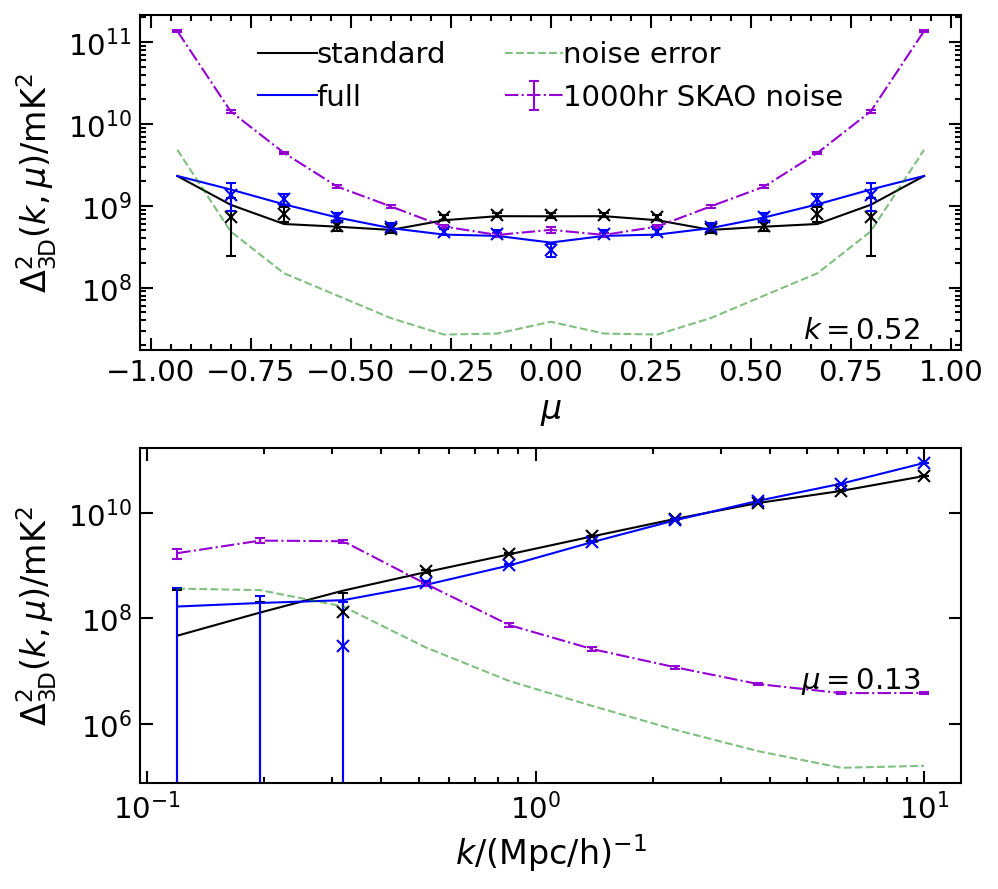

[[           nan 1.15750360e+09 2.30669930e+09 3.50073001e+09
  4.38674133e+09 4.83742673e+09 6.02283937e+09 1.17977838e+10
             nan            nan            nan            nan]
 [           nan 8.71838542e+08 1.40450554e+09 9.79735979e+08
  9.04411551e+08 4.86908281e+08 9.63510548e+07 1.94626849e+07
  4.64231275e+07            nan            nan            nan]
 [3.11838602e+08 8.25997123e+08 1.01907932e+09 6.04197271e+08
  4.08850558e+08 1.50054204e+08 2.28226901e+07 6.45214871e+06
  7.06219783e+06            nan            nan            nan]
 [2.76053216e+08            nan 6.94951159e+08 4.57238787e+08
  2.49454286e+08 8.01084400e+07 1.16551538e+07 3.48174241e+06
  1.96243954e+06 1.52906646e+07            nan            nan]
 [           nan 6.75535089e+08 4.94308845e+08 3.15543910e+08
  2.23768461e+08 4.25660266e+07 7.58384067e+06 2.74958797e+06
  1.00575136e+06 9.07430971e+05            nan            nan]
 [           nan 4.92504430e+08 5.82351502e+08 3.16449352e+08
  2

In [ ]:
#calculate errors
err_lc_res= np.empty_like(nmode_res1)
err_rsd_res= np.empty_like(nmode_res1)
err_noise = np.empty_like(nmode_res1)
standard_noise_error = 1/np.sqrt(nmode_NOISE)
#calculate errors
errors = np.loadtxt(base + 'errors_on_FastICA_CD_mups.txt')
errors = errors.reshape((mubins,kbins,3))
err_lc_res= errors[:,:,1]
err_rsd_res= errors[:,:,0]
err_noise = errors[:,:,2]
        
ii = 5
jj = 8

fig, ax = plt.subplots(figsize=(fig_width, fig_height),
                       nrows=2, ncols=1,)



ax[0].plot(mubins_1, dk_lc[:,ii], color='k', label='standard')
ax[0].errorbar(mubins_res1, dk_lc_res1[:,ii], yerr= err_lc_res[:,ii], color='k', linestyle='none', capsize=2.5, marker='x')
ax[0].plot(mubins_rsd, dk_rsd_lc[:,ii], color='b', label='full')
ax[0].errorbar(mubins_resrsd, dk_rsd_res1[:,ii], yerr= err_rsd_res[:,ii], color='b', linestyle='none',  marker='x', capsize=2.5)
ax[0].plot(mubins_rsd, err_noise[:,ii], color='g',  label='noise error', linestyle='dashed', alpha=0.5)
ax[0].errorbar(mubins_NOISE, dk_NOISE[:,ii], err_noise[:,ii], color='darkviolet', linestyle='dashdot', label='1000hr SKAO noise', capsize=2.5)
ax[0].set_yscale('log')
ax[0].set_xlabel(r'$\mu$', fontsize=16)
ax[0].set_ylabel(r'$\Delta^2_{\rm 3D}(k,\mu)/ \rm mK^2$', fontsize=16)
ax[0].text(0.95, 0.1, r' $k={0:.2f}$'.format(kbins_1[ii]), transform=ax[0].transAxes, ha='right', va='top', fontsize=14)
ax[0].legend(frameon=False, fontsize = 14, ncol=2)
#ax[0].set_xlim(-0.5,0.5)
 
ax[1].plot(kbins_1, dk_lc[jj,:], color='k') 
ax[1].errorbar(kbins_res1, dk_lc_res1[jj,:], yerr= err_lc_res[jj,:], color='k', linestyle='none', marker='x', capsize=2.5)
ax[1].plot(kbins_rsd, dk_rsd_lc[jj,:], color='b')
ax[1].errorbar(kbins_resrsd, dk_rsd_res1[jj,:], yerr= err_rsd_res[jj,:], color='b', linestyle='none', marker='x', capsize=2.5)
ax[1].errorbar(kbins_NOISE, dk_NOISE[jj,:], err_noise[jj,:], color='darkviolet', linestyle='dashdot', capsize=2.5)
ax[1].plot(kbins_NOISE, err_noise[jj,:], color='g', label='noise error', linestyle='dashed', alpha=0.5)
ax[1].set_xlabel(r'$k/(\rm Mpc/h)^{-1}$', fontsize=16)
ax[1].set_ylabel(r'$\Delta^2_{\rm 3D}(k,\mu)/ \rm mK^2$', fontsize=16)
ax[1].text(0.95, 0.35, r' $\mu={0:.2f}$'.format(mubins_1[jj]), transform=ax[1].transAxes, ha='right', va='top', fontsize=14)
ax[1].set_yscale('log')
ax[1].set_xscale('log')
plt.tight_layout()
plt.savefig(base + 'graphs_for_paper/CD_Fg_4c_fastica_recovery_mu_allks_NOISE.pdf', dpi=330, bbox_inches='tight')
plt.show()

print(err_noise - standard_noise_error)

print(dk_rsd_res[jj, -1])
print((np.abs(dk_rsd_res[jj, -1]-dk_lc_res[jj, -1])/dk_lc_res[jj, -1])*100)
print((np.abs(dk_rsd_lc[jj, -1]-dk_lc[jj, -1])/dk_lc[jj, -1])*100)

In [ ]:

p_lc_eor_res, k_lc_eor_res, n_lc_res = t2c.power_spectrum_1d(resids_LC_FG_NOISE[:,:,i0:i1],  box_dims=box_dims, kbins=kbins, binning = 'log', return_n_modes=True)
p_rsd_lc_eor_res, k_rsd_lc_eor_res, n_rsd_res = t2c.power_spectrum_1d(resids_RSD_FG_NOISE[:,:,i0:i1],  box_dims=box_dims, kbins=kbins, binning = 'log', return_n_modes=True)
p_lc_eor, k_lc_eor, n_lc = t2c.power_spectrum_1d(LC_z01_nu01_1deg[:,:,i0:i1],  box_dims=box_dims, kbins=kbins, binning = 'log', return_n_modes=True)
p_rsd_lc_eor, k_rsd_lc_eor, n_rsd = t2c.power_spectrum_1d(RSD_z01_nu01_1deg[:,:,i0:i1],  box_dims=box_dims, kbins=kbins, binning = 'log', return_n_modes=True)
        
d_lc_eor = (p_lc_eor*V_eor*k_lc_eor**3)/(2*np.pi**2)
d_rsd_lc_eor = (p_rsd_lc_eor*V_eor*k_rsd_lc_eor**3)/(2*np.pi**2)
d_lc_eor_res = (p_lc_eor_res*V_eor*k_lc_eor_res**3)/(2*np.pi**2)
d_rsd_lc_eor_res = (p_rsd_lc_eor_res*V_eor*k_rsd_lc_eor_res**3)/(2*np.pi**2)



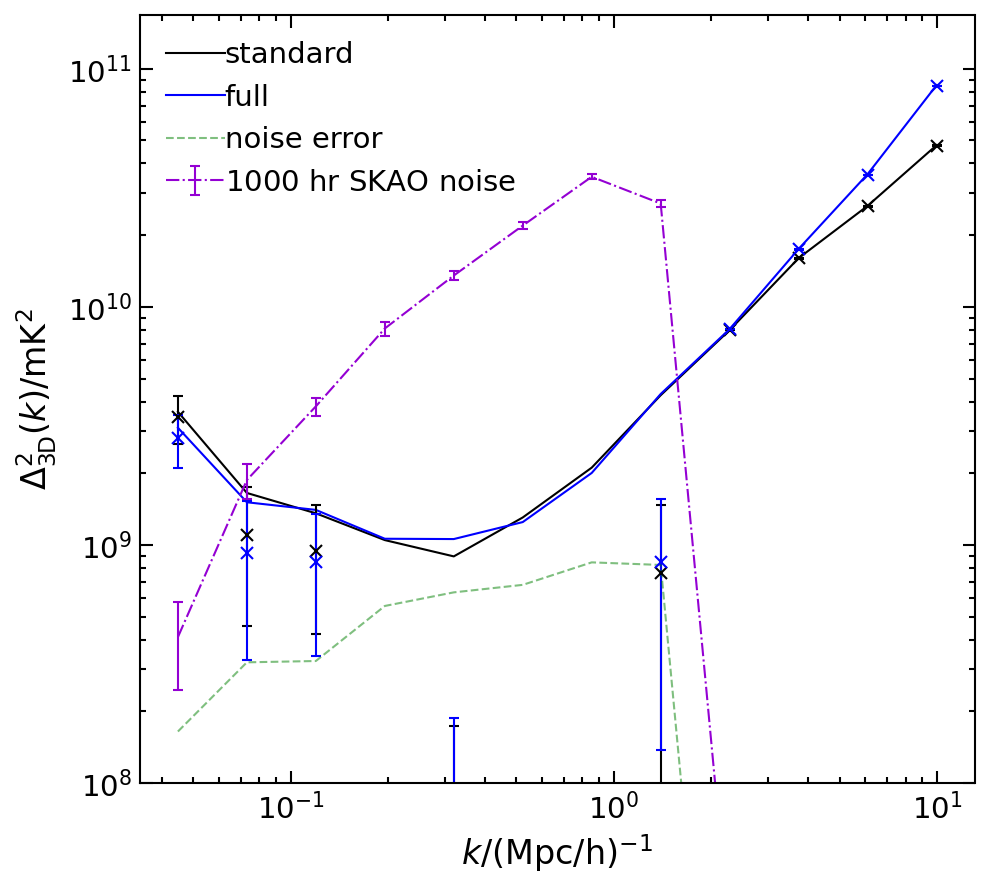

78.65464281101234
77.93969989739745
[1.64584847e+08 3.21362077e+08 3.25470320e+08 5.54245194e+08
 6.32144174e+08 6.79738763e+08 8.44889402e+08 8.23982359e+08
 6.94736446e+05 2.00910694e+05 1.11329663e+05 9.88185108e+04]


In [ ]:
d_rsd_res = d_rsd_lc_eor_res - d_NOISE
d_lc_res = d_lc_eor_res - d_NOISE

#calculate errors
errors = np.loadtxt(base + 'errors_on_FastICA_CD_1Dps.txt')
e_lc_res= errors[:,1]
e_rsd_res= errors[:,0]
e_noise = errors[:,2]
        
        
        

fig, ax = plt.subplots(figsize=(fig_width, fig_height),
                       nrows=1, ncols=1)
ax.plot(k_lc_eor, d_lc_eor, color='k', label='standard') 
ax.plot(k_rsd_lc_eor, d_rsd_lc_eor, color='b', label='full')
ax.errorbar(k_lc_eor_res, d_lc_res, e_lc_res, color='k', linestyle='none', marker='x', capsize=2.5)
ax.errorbar(k_rsd_lc_eor_res, d_rsd_res, e_rsd_res, linestyle='none', marker='x', capsize=2.5, color='b')
ax.errorbar(k_NOISE, d_NOISE, e_noise, capsize=2.5, color='darkviolet', linestyle='dashdot', label=r'1000 $ \rm hr$ SKAO noise')
ax.plot(k_NOISE, e_noise, color='g', label='noise error', linestyle='dashed', alpha=0.5)
ax.set_ylabel(r'$\Delta_{\rm 3D} ^2(k)/\rm mK^2$', fontsize=16)
ax.set_xlabel(r'$k/(\rm Mpc/h)^{-1}$', fontsize=16)
ax.set_yscale('log')
ax.set_xscale('log')
ax.legend(frameon=False, fontsize = 14)
ax.set_ylim(bottom = 100000000)
plt.tight_layout()
plt.savefig(base + 'graphs_for_paper/CD_Fg_4c_fastica_recovery_1Dps_NOISE.pdf', dpi=330, bbox_inches='tight')
plt.show()

print((np.abs(d_rsd_lc_eor[-1]-d_lc_eor[-1])/d_lc_eor[-1])*100)
print((np.abs(d_rsd_res[-1]-d_lc_res[-1])/d_lc_res[-1])*100)

standard_noise_error = 1/np.sqrt(n_NOISE)
print(e_noise - standard_noise_error)

In [ ]:
from scipy import interpolate
import matplotlib.colors as colors

plotting_scale={'x': 'log', 'y': 'log', 'z': 'log'}

bins = 8

L_para, L_perp = get_lengths(freq[i0], freq[i1], (freq[i0]+freq[i1])/2, 1.0)
box_dims = [L_perp, L_perp, L_para]

pp_NOISE, kper_NOISE, kpar_NOISE, n_NOISE = t2c.power_spectrum_2d(NOISE[:,:,i0:i1], kbins=bins, box_dims= box_dims, return_modes=True)
for ii in range(0,len(kper_NOISE)):
    for jj in range(0,len(kpar_NOISE)):
        pp_NOISE[ii,jj] = (pp_NOISE[ii,jj]*V_eor*np.sqrt(kper_NOISE[ii]**2 + kpar_NOISE[jj]**2)**3)/(2*np.pi**2)
        
fp_NOISE = interpolate.interp2d(kper_NOISE, kpar_NOISE, pp_NOISE.T, kind='linear')
X_NOISE, Y_NOISE = kper_NOISE, kpar_NOISE
C_NOISE = fp_NOISE(X_NOISE,Y_NOISE)
norm_NOISE = colors.LogNorm(vmin=C_NOISE[np.isfinite(C_NOISE)].min(), vmax=C_NOISE[np.isfinite(C_NOISE)].max()) if plotting_scale['z']=='log' else None 


pp_RSD_RES, kper_RSD_RES, kpar_RSD_RES, n_RSD_RES = t2c.power_spectrum_2d(resids_RSD_FG_NOISE[:,:,i0:i1], kbins=bins, box_dims= box_dims, return_modes=True)
for ii in range(0,len(kper_RSD_RES)):
    for jj in range(0,len(kpar_RSD_RES)):
        pp_RSD_RES[ii,jj] = (pp_RSD_RES[ii,jj]*V_eor*np.sqrt(kper_RSD_RES[ii]**2 + kpar_RSD_RES[jj]**2)**3)/(2*np.pi**2)
        
err_RSD_RES = 1/np.sqrt(n_RSD_RES)
fp_RSD_RES = interpolate.interp2d(kper_RSD_RES, kpar_RSD_RES, pp_RSD_RES.T, kind='linear')
X_RSD_RES, Y_RSD_RES = kper_RSD_RES, kpar_RSD_RES
C_RSD_RES = fp_RSD_RES(X_RSD_RES,Y_RSD_RES)
C_RSD_RES = C_RSD_RES - C_NOISE
norm_RSD_RES = colors.LogNorm(vmin=C_RSD_RES[np.isfinite(C_RSD_RES)].min(), vmax=C_RSD_RES[np.isfinite(C_RSD_RES)].max()) if plotting_scale['z']=='log' else None 


pp_LC_RES, kper_LC_RES, kpar_LC_RES, n_LC_RES = t2c.power_spectrum_2d(resids_LC_FG_NOISE[:,:,i0:i1], kbins=bins, box_dims= box_dims, return_modes=True)
for ii in range(0,len(kper_LC_RES)):
    for jj in range(0,len(kpar_LC_RES)):
        pp_LC_RES[ii,jj] = (pp_LC_RES[ii,jj]*V_eor*np.sqrt(kper_LC_RES[ii]**2 + kpar_LC_RES[jj]**2)**3)/(2*np.pi**2)
        
err_LC_RES = 1/np.sqrt(n_LC_RES)
fp_LC_RES = interpolate.interp2d(kper_LC_RES, kpar_LC_RES, pp_LC_RES.T, kind='linear')
X_LC_RES, Y_LC_RES = kper_LC_RES, kpar_LC_RES
C_LC_RES = fp_LC_RES(X_LC_RES,Y_LC_RES)
C_LC_RES = C_LC_RES - C_NOISE
norm_LC_RES = colors.LogNorm(vmin=C_LC_RES[np.isfinite(C_LC_RES)].min(), vmax=C_LC_RES[np.isfinite(C_LC_RES)].max()) if plotting_scale['z']=='log' else None 

In [ ]:
pp_RSD, kper_RSD, kpar_RSD, n_RSD = t2c.power_spectrum_2d(RSD_z01_nu01_1deg[:,:,i0:i1], kbins=bins, box_dims= box_dims, return_modes=True)
for ii in range(0,len(kper_RSD)):
    for jj in range(0,len(kpar_RSD)):
        pp_RSD[ii,jj] = (pp_RSD[ii,jj]*V_eor*np.sqrt(kper_RSD[ii]**2 + kpar_RSD[jj]**2)**3)/(2*np.pi**2)
fp_RSD = interpolate.interp2d(kper_RSD, kpar_RSD, pp_RSD.T, kind='linear')
X_RSD, Y_RSD = kper_RSD, kpar_RSD
C_RSD = fp_RSD(X_RSD,Y_RSD)
norm_RSD = colors.LogNorm(vmin=C_RSD[np.isfinite(C_RSD)].min(), vmax=C_RSD[np.isfinite(C_RSD)].max()) if plotting_scale['z']=='log' else None 

pp_LC, kper_LC, kpar_LC, n_LC = t2c.power_spectrum_2d(LC_z01_nu01_1deg[:,:,i0:i1], kbins=bins, box_dims= box_dims, return_modes=True)
for ii in range(0,len(kper_LC)):
    for jj in range(0,len(kpar_LC)):
        pp_LC[ii,jj] = (pp_LC[ii,jj]*V_eor*np.sqrt(kper_LC[ii]**2 + kpar_LC[jj]**2)**3)/(2*np.pi**2)
fp_LC = interpolate.interp2d(kper_LC, kpar_LC, pp_LC.T, kind='linear')
X_LC, Y_LC = kper_LC, kpar_LC
C_LC = fp_LC(X_LC,Y_LC)
norm_LC = colors.LogNorm(vmin=C_LC[np.isfinite(C_LC)].min(), vmax=C_LC[np.isfinite(C_LC)].max()) if plotting_scale['z']=='log' else None 

C_diff = (np.abs(C_RSD - C_LC)/C_LC)*100
norm_diff = colors.LogNorm(vmin=C_diff[np.isfinite(C_diff)].min(), vmax=C_diff[np.isfinite(C_diff)].max()) if plotting_scale['z']=='log' else None 

C_diff_res =  (np.abs(C_RSD_RES - C_LC_RES)/C_LC_RES)*100
norm_diff_res = colors.LogNorm(vmin=C_diff_res[np.isfinite(C_diff_res)].min(), vmax=C_diff_res[np.isfinite(C_diff_res)].max()) if plotting_scale['z']=='log' else None 

highlighted_pixels = np.zeros([2,18])
uu=0
for ii in range(0, C_RSD_RES.shape[0]):
    for jj in range(0, C_RSD_RES.shape[1]):
        if C_RSD_RES[ii,jj] <= 0 or C_LC_RES[ii,jj] <= 0:
            highlighted_pixels[0,uu] = ii
            highlighted_pixels[1,uu] = jj
            C_RSD_RES[ii,jj] = 1e5
            uu+=1
        else:
            continue
        
for ii in range(0, C_LC_RES.shape[0]):
    for jj in range(0, C_LC_RES.shape[1]):
        if C_LC_RES[ii,jj] <= 0:
            C_LC_RES[ii,jj] = 1e5
        else:
            continue
        
C_tot = np.concatenate((C_LC, C_RSD, C_LC_RES, C_RSD_RES))
norm_tot = colors.LogNorm(vmin=C_tot[np.isfinite(C_tot)].min(), vmax=C_tot[np.isfinite(C_tot)].max()) if plotting_scale['z']=='log' else None

print(pearson_correl(C_diff_res.reshape(8*8),C_diff.reshape(8*8)))

for ii in range(0, C_diff_res.shape[0]):
    for jj in range(0, C_diff_res.shape[1]):
        if C_diff_res[ii,jj] <= 0:
            C_diff_res[ii,jj] =  1e5
        else:
            continue
        
        

        
        
C_tot_diff = np.concatenate((C_diff, C_diff_res))
norm_tot_diff = colors.LogNorm(vmin=C_tot_diff[np.isfinite(C_tot_diff)].min(), vmax=C_tot_diff[np.isfinite(C_tot_diff)].max()) if plotting_scale['z']=='log' else None 

0.0919298701369011


In [ ]:
#calculate errors
errors = np.loadtxt(base + 'errors_on_FastICA_CD_cyclindricalps.txt')
errors = errors.reshape((bins,bins,2))
err_lc= errors[:,:,0]
err_rsd= errors[:,:,1]

noise_pixels_LC= np.zeros([2,C_LC.shape[0]*C_LC.shape[1]])
uu=0
print(C_LC.shape)
for ii in range(0, C_LC.shape[0]):
    for jj in range(0, C_LC.shape[1]):
        if err_lc[ii,jj] >= C_LC[ii,jj]:
            noise_pixels_LC[0,uu] = ii
            noise_pixels_LC[1,uu] = jj
            uu+=1
        else:
            continue
        
noise_pixels_RSD= np.zeros([2,C_RSD.shape[0]*C_RSD.shape[1]])
uu=0
for ii in range(0, C_RSD.shape[0]):
    for jj in range(0, C_RSD.shape[1]):
        if err_rsd[ii,jj] >= C_RSD[ii,jj]:
            noise_pixels_RSD[0,uu] = ii
            noise_pixels_RSD[1,uu] = jj
            uu+=1
        else:
            continue

(8, 8)


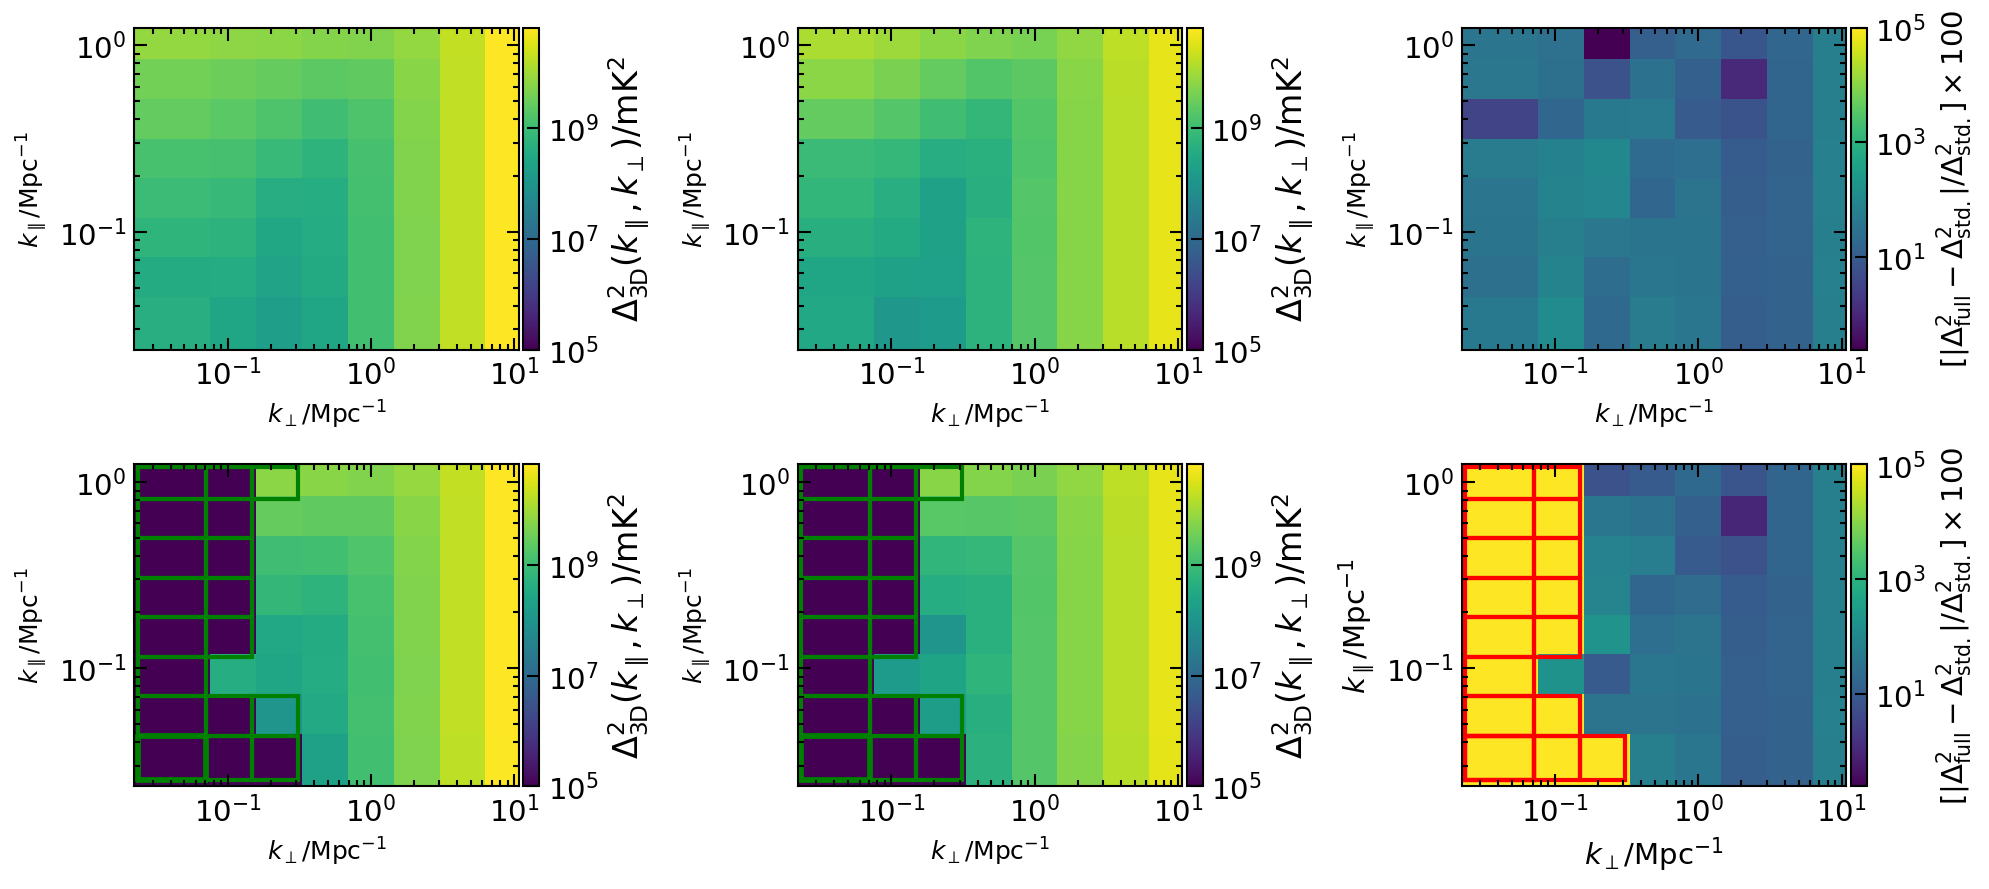

In [ ]:
import matplotlib.patches as patches
import matplotlib.font_manager
import matplotlib as mpl


fig, ax = plt.subplots(figsize=(2*fig_width, fig_height),
                       nrows=2, ncols=3,)
    
pcm_RSD = ax[0,0].pcolormesh(X_RSD, Y_RSD, C_RSD, norm=norm_tot, cmap='viridis')
cbar= plt.colorbar(pcm_RSD, ax=ax[0,0], pad=0.01)
cbar.set_label(r'$\Delta^2_{\rm 3D}(k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
ax[0,0].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$')
ax[0,0].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$')
ax[0,0].set_xscale(plotting_scale['x'])
ax[0,0].set_yscale(plotting_scale['y'])
  

pcm_LC = ax[0,1].pcolormesh(X_LC, Y_LC, C_LC, norm=norm_tot, cmap='viridis')
cbar= plt.colorbar(pcm_LC, ax=ax[0,1], pad=0.01)
cbar.set_label(r'$\Delta^2_{\rm 3D}(k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
ax[0,1].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$')
ax[0,1].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$')
ax[0,1].set_xscale(plotting_scale['x'])
ax[0,1].set_yscale(plotting_scale['y'])
   

pcm_LC = ax[0,2].pcolormesh(X_LC, Y_LC, C_diff, norm=norm_tot_diff, cmap='viridis')
cbar= plt.colorbar(pcm_LC, ax=ax[0,2], pad=0.01)
cbar.set_label(r'$[|\Delta^2_{\rm full} - \Delta^2_{\rm std.}|/\Delta^2_{\rm std.}] \times 100 $', size=14)
ax[0,2].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$')
ax[0,2].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$')
ax[0,2].set_xscale(plotting_scale['x'])
ax[0,2].set_yscale(plotting_scale['y'])
    

pcm_RSD_RES = ax[1,0].pcolormesh(X_RSD_RES, Y_RSD_RES, C_RSD_RES, norm=norm_tot, cmap='viridis')
cbar= plt.colorbar(pcm_RSD_RES, ax=ax[1,0], pad=0.01)
cbar.set_label(r'$\Delta^2_{\rm 3D}(k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
ax[1,0].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$')
ax[1,0].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$')
ax[1,0].set_xscale(plotting_scale['x'])
ax[1,0].set_yscale(plotting_scale['y'])


pcm_LC_RES = ax[1,1].pcolormesh(X_LC_RES, Y_LC_RES, C_LC_RES, norm=norm_tot, cmap='viridis')
cbar= plt.colorbar(pcm_LC_RES, ax=ax[1,1], pad=0.01)
cbar.set_label(r'$\Delta^2_{\rm 3D}(k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
ax[1,1].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$')
ax[1,1].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$')
ax[1,1].set_xscale(plotting_scale['x'])
ax[1,1].set_yscale(plotting_scale['y'])
    

pcm_LC_RES = ax[1,2].pcolormesh(X_LC_RES, Y_LC_RES, C_diff_res, norm=norm_tot_diff, cmap='viridis') #fix diff like emma suggested
cbar= plt.colorbar(pcm_LC_RES, ax=ax[1,2], pad=0.01)
cbar.set_label(r'$[|\Delta^2_{\rm full} - \Delta^2_{\rm std.}|/\Delta^2_{\rm std.}] \times 100 $', size=14)

# Compute bin edges from centers
x_edges = np.sqrt(X_LC_RES[:-1] * X_LC_RES[1:])
x_edges = np.concatenate(([X_LC_RES[0]**2 / X_LC_RES[1]], x_edges, [X_LC_RES[-1]**2 / X_LC_RES[-2]]))

y_edges = np.sqrt(Y_LC_RES[:-1] * Y_LC_RES[1:])
y_edges = np.concatenate(([0.025], y_edges, [1.2]))
for row, col in highlighted_pixels.T:
    col = int(col)
    row = int(row)
    x_start = x_edges[col]      # Left edge
    y_start = y_edges[row]      # Bottom edge
    x_end = x_edges[col + 1]    # Right edge
    y_end = y_edges[row + 1]    # Top edge

    width = x_end - x_start
    height = y_end - y_start

    rect = patches.Rectangle((x_start, y_start), width, height,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax[1,2].add_patch(rect)
    
#add in level of noise error
for row, col in noise_pixels_RSD.T:
    col = int(col)
    row = int(row)
    x_start = x_edges[col]      # Left edge
    y_start = y_edges[row]      # Bottom edge
    x_end = x_edges[col + 1]    # Right edge
    y_end = y_edges[row + 1]    # Top edge

    width = x_end - x_start
    height = y_end - y_start

    rect = patches.Rectangle((x_start, y_start), width, height,
                             linewidth=2, edgecolor='k', facecolor='none')
    ax[1,0].add_patch(rect)
    
#add in level of noise error
for row, col in noise_pixels_RSD.T:
    col = int(col)
    row = int(row)
    x_start = x_edges[col]      # Left edge
    y_start = y_edges[row]      # Bottom edge
    x_end = x_edges[col + 1]    # Right edge
    y_end = y_edges[row + 1]    # Top edge

    width = x_end - x_start
    height = y_end - y_start

    rect = patches.Rectangle((x_start, y_start), width, height,
                             linewidth=2, edgecolor='k', facecolor='none')
    ax[1,1].add_patch(rect)

ax[1,2].set_xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
ax[1,2].set_ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
ax[1,2].set_xscale(plotting_scale['x'])
ax[1,2].set_yscale(plotting_scale['y'])
    
plt.tight_layout()
plt.savefig(base + 'graphs_for_paper/cyclindrical_powerSpec_FGremoval_512_80-90MHz_NOISE.pdf', dpi=330, bbox_inches='tight')
plt.show()